In [ ]:
# ============================================================
# BUSINESS ANALYTICS – END TERM PROJECT
# Airbnb Listings Data Analysis
# ============================================================

In [ ]:
# -----------------------------
# 1. Import Libraries
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, r2_score, classification_report

import statsmodels.api as sm

In [ ]:
# -----------------------------
# 2. Load Dataset
# -----------------------------

df = pd.read_excel("Airbnb_data_Selected_Info.xlsx")

In [ ]:
df


,id,Price (USD),property_type,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,city,host_identity_verified,host_has_profile_pic,number_of_reviews,review_scores_rating,bedrooms,beds
0,13662370,45.0,House,Private room,2,1,strict,True,Chicago,t,t,17,97.0,1,1
1,4765892,140.0,Apartment,Entire home/apt,2,2,strict,True,LA,t,t,2,100.0,1,1
2,21169968,140.0,Apartment,Entire home/apt,5,1,moderate,True,NYC,t,t,25,88.0,2,3
3,7939196,130.0,Apartment,Entire home/apt,6,1,strict,True,NYC,t,t,12,82.0,1,3
4,18161036,39.0,House,Private room,2,1,flexible,True,LA,t,t,2,100.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37051,16015983,400.0,Apartment,Entire home/apt,4,1,flexible,False,Boston,f,t,0,NaN,1,1
37052,12545769,65.0,Other,Private room,2,1,strict,True,NYC,f,t,7,91.0,1,1
37053,10100121,190.0,Apartment,Entire home/apt,2,1,flexible,True,DC,t,t,12,98.0,1,1
37054,19260393,95.0,Apartment,Private room,2,1,moderate,True,NYC,f,t,6,97.0,1,1


In [ ]:
# Rename columns for simplicity
df = df.rename(columns={
    'Price (USD)': 'Price',
    'accommodates': 'Accommodates',
    'bathrooms': 'Bathrooms',
    'number_of_reviews': 'Number_of_Reviews',
    'review_scores_rating': 'Review_Score_Rating',
    'cleaning_fee': 'Cleaning_Fee',
    'bedrooms': 'Bedrooms',
    'beds': 'Beds'
})

In [ ]:
df

,id,Price,property_type,room_type,Accommodates,Bathrooms,cancellation_policy,Cleaning_Fee,city,host_identity_verified,host_has_profile_pic,Number_of_Reviews,Review_Score_Rating,Bedrooms,Beds
0,13662370,45.0,House,Private room,2,1,strict,True,Chicago,t,t,17,97.0,1,1
1,4765892,140.0,Apartment,Entire home/apt,2,2,strict,True,LA,t,t,2,100.0,1,1
2,21169968,140.0,Apartment,Entire home/apt,5,1,moderate,True,NYC,t,t,25,88.0,2,3
3,7939196,130.0,Apartment,Entire home/apt,6,1,strict,True,NYC,t,t,12,82.0,1,3
4,18161036,39.0,House,Private room,2,1,flexible,True,LA,t,t,2,100.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37051,16015983,400.0,Apartment,Entire home/apt,4,1,flexible,False,Boston,f,t,0,NaN,1,1
37052,12545769,65.0,Other,Private room,2,1,strict,True,NYC,f,t,7,91.0,1,1
37053,10100121,190.0,Apartment,Entire home/apt,2,1,flexible,True,DC,t,t,12,98.0,1,1
37054,19260393,95.0,Apartment,Private room,2,1,moderate,True,NYC,f,t,6,97.0,1,1


In [ ]:
print("Dataset Shape:", df.shape)


Dataset Shape: (37056, 15)


In [ ]:
df.head()

,id,Price,property_type,room_type,Accommodates,Bathrooms,cancellation_policy,Cleaning_Fee,city,host_identity_verified,host_has_profile_pic,Number_of_Reviews,Review_Score_Rating,Bedrooms,Beds
0,13662370,45.0,House,Private room,2,1,strict,True,Chicago,t,t,17,97.0,1,1
1,4765892,140.0,Apartment,Entire home/apt,2,2,strict,True,LA,t,t,2,100.0,1,1
2,21169968,140.0,Apartment,Entire home/apt,5,1,moderate,True,NYC,t,t,25,88.0,2,3
3,7939196,130.0,Apartment,Entire home/apt,6,1,strict,True,NYC,t,t,12,82.0,1,3
4,18161036,39.0,House,Private room,2,1,flexible,True,LA,t,t,2,100.0,1,1


In [ ]:
# -----------------------------
# 3. Exploratory Data Analysis
# -----------------------------

df.isnull().sum()

,0
id,0
Price,0
property_type,0
room_type,0
Accommodates,0
Bathrooms,0
cancellation_policy,0
Cleaning_Fee,0
city,0
host_identity_verified,86


In [ ]:
df_clean = df.dropna(subset=[
    'Price','Accommodates','Bathrooms',
    'Number_of_Reviews','Bedrooms',
    'Beds','Review_Score_Rating'
]).copy()


In [ ]:
df_clean.shape

(28661, 15)

In [ ]:
df_clean[['Price','Accommodates','Bathrooms',
          'Number_of_Reviews','Bedrooms',
          'Beds','Review_Score_Rating']].describe()

,Price,Accommodates,Bathrooms,Number_of_Reviews,Bedrooms,Beds,Review_Score_Rating
count,28661.000000,28661.000000,28661.000000,28661.000000,28661.000000,28661.000000,28661.000000
mean,147.306863,3.213949,1.180664,27.086389,1.256411,1.732389,94.040054
std,134.170287,2.146648,0.523373,41.349821,0.838881,1.255462,7.925609
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,20.000000
25%,73.000000,2.000000,1.000000,3.000000,1.000000,1.000000,92.000000
50%,110.000000,2.000000,1.000000,11.000000,1.000000,1.000000,96.000000
75%,175.000000,4.000000,1.000000,33.000000,1.000000,2.000000,100.000000
max,1999.000001,16.000000,8.000000,605.000000,10.000000,16.000000,100.000000


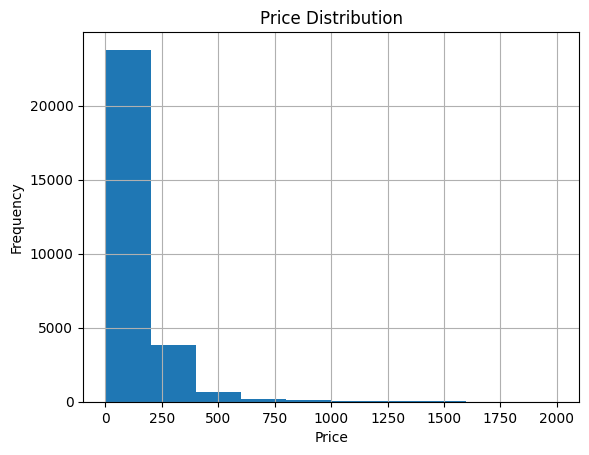

In [ ]:
# Price Distribution
plt.figure()
df_clean['Price'].hist()
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

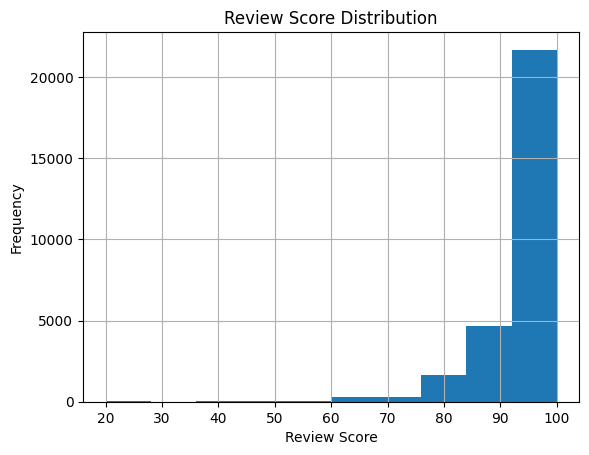

In [ ]:
# Review Score Distribution
plt.figure()
df_clean['Review_Score_Rating'].hist()
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Frequency")
plt.show()

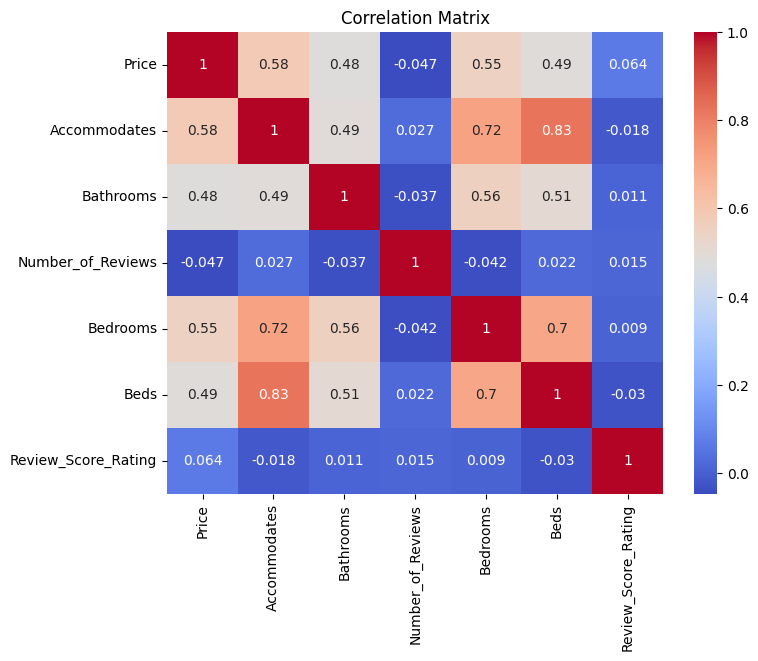

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df_clean[['Price','Accommodates','Bathrooms',
              'Number_of_Reviews','Bedrooms',
              'Beds','Review_Score_Rating']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# -----------------------------
# 4. K-Means Clustering
# -----------------------------

cluster_vars = ['Price','Accommodates','Bathrooms',
                'Number_of_Reviews','Bedrooms','Beds']

cluster_data = df_clean[cluster_vars]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

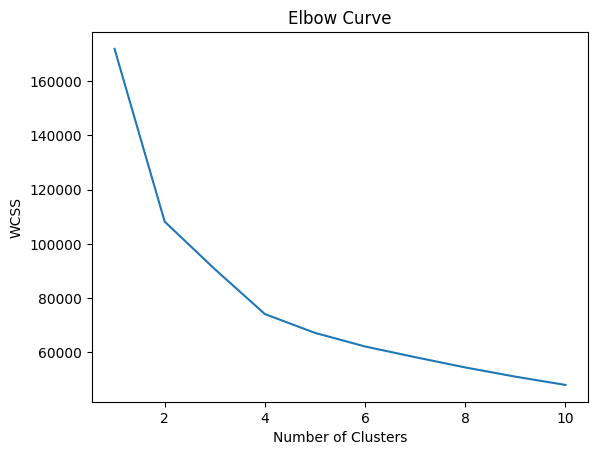

In [ ]:
# Elbow Method
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

plt.figure()
plt.plot(range(1,11), wcss)
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df_clean.loc[:, 'Cluster'] = kmeans.fit_predict(scaled_data)

In [ ]:

df_clean['Cluster'].value_counts()

df_clean.groupby('Cluster')[cluster_vars].mean()

,Price,Accommodates,Bathrooms,Number_of_Reviews,Bedrooms,Beds
Cluster,,,,,,
0,115.949551,2.544684,1.054915,15.478011,1.015085,1.358702
1,340.399546,7.083544,1.959112,22.015396,2.753912,3.926300
2,119.382438,2.979681,1.062772,126.801161,1.025036,1.553701


In [ ]:
# -----------------------------
# 5. Logistic Regression
# -----------------------------

largest_cluster = df_clean['Cluster'].value_counts().idxmax()
df_cluster = df_clean[df_clean['Cluster'] == largest_cluster].copy()

In [ ]:
df_cluster['Very_High_Score'] = np.where(
    df_cluster['Review_Score_Rating'] >= 98, 1, 0
)

In [ ]:
model_vars = ['Price','Bathrooms','Bedrooms','Beds','Cleaning_Fee']


In [ ]:
df_cluster = df_cluster.dropna(subset=model_vars)

In [ ]:
X = df_cluster[model_vars]
y = df_cluster['Very_High_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

In [ ]:
# Logistic Model
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

In [ ]:
# -----------------------------
# Model Evaluation
# -----------------------------

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred, zero_division=0))
print("Recall Score:", recall_score(y_test, y_pred, zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Confusion Matrix:
[[690 565]
 [461 479]]

Accuracy Score: 0.5325740318906605
Precision Score: 0.45881226053639845
Recall Score: 0.5095744680851064

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.55      0.57      1255
           1       0.46      0.51      0.48       940

    accuracy                           0.53      2195
   macro avg       0.53      0.53      0.53      2195
weighted avg       0.54      0.53      0.53      2195



In [ ]:
# -----------------------------
# Logistic Regression (p-values)
# -----------------------------

# Ensure numeric format for statsmodels

X_train_numeric = X_train.copy()
if 'Cleaning_Fee' in X_train_numeric.columns:
    X_train_numeric['Cleaning_Fee'] = X_train_numeric['Cleaning_Fee'].astype(int)

X_train_sm = sm.add_constant(X_train_numeric.astype(float))
logit_model = sm.Logit(y_train.astype(float), X_train_sm).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.677161
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        Very_High_Score   No. Observations:                19748
Model:                          Logit   Df Residuals:                    19742
Method:                           MLE   Df Model:                            5
Date:                Thu, 19 Feb 2026   Pseudo R-squ.:                0.009403
Time:                        21:39:48   Log-Likelihood:                -13373.
converged:                       True   LL-Null:                       -13500.
Covariance Type:            nonrobust   LLR p-value:                 8.062e-53
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1165      0.073     -1.589      0.112      -0.260       0.027
Price            0.0026

The pseudo R² value of 0.009 indicates that the selected structural variables explain less than 1% of the variation in extremely high ratings. Although some predictors such as price, bedrooms, beds, and cleaning fee are statistically significant, their overall explanatory power is limited. This suggests that achieving very high ratings (≥98) is not primarily driven by physical property characteristics.

In [ ]:
# ------------------------------------------------------------
# 6. Linear Regression
# ------------------------------------------------------------

y_cont = df_cluster['Review_Score_Rating']
X_cont = df_cluster[model_vars].copy()

# Fix: Convert boolean Cleaning_Fee to integer for regression
if 'Cleaning_Fee' in X_cont.columns:
    X_cont['Cleaning_Fee'] = X_cont['Cleaning_Fee'].astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cont, y_cont, test_size=0.10, random_state=42
)

# Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train_c, y_train_c)

y_pred_c = lin_model.predict(X_test_c)

# R-squared
print("R-squared Score:", r2_score(y_test_c, y_pred_c))

# OLS with p-values
X_train_c_sm = sm.add_constant(X_train_c.astype(float))
ols_model = sm.OLS(y_train_c.astype(float), X_train_c_sm).fit()
print(ols_model.summary())

R-squared Score: 0.0003778959525350123
                             OLS Regression Results                            
Dep. Variable:     Review_Score_Rating   R-squared:                       0.011
Model:                             OLS   Adj. R-squared:                  0.010
Method:                  Least Squares   F-statistic:                     42.31
Date:                 Thu, 19 Feb 2026   Prob (F-statistic):           1.66e-43
Time:                         21:39:48   Log-Likelihood:                -69848.
No. Observations:                19748   AIC:                         1.397e+05
Df Residuals:                    19742   BIC:                         1.398e+05
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

The R² value of 0.011 indicates that only 1.1% of the variation in review scores is explained by the selected independent variables. While some predictors are statistically significant, their practical impact on overall rating is minimal. This implies that structural property features alone do not strongly determine customer satisfaction.

**CONCLUSION**

The analysis reveals that while certain structural variables such as price, bedrooms, beds, and cleaning fee are statistically significant, their overall explanatory power is limited. Both the logistic and linear regression models exhibit very low R² and pseudo R² values, indicating that property characteristics explain only a small proportion of variation in customer ratings. This suggests that achieving high customer satisfaction on Airbnb is influenced more by qualitative factors such as host responsiveness, service quality, communication effectiveness, and location advantages rather than purely structural attributes. Therefore, hosts aiming to improve ratings should focus more on enhancing guest experience and service quality in addition to property features. This study is limited by the exclusion of qualitative variables such as host communication and service quality due to data constraints.